In [1]:
TRAIN_PATH = 'Weibo Data/weibo_train_data/weibo_train_data.txt'
PREDICT_PATH = 'Weibo Data/weibo_predict_data/weibo_predict_data.txt'
RESULT_PATH = 'Weibo Data/weibo_result_data/weibo_result_data.txt'

In [2]:
import pandas as pd

# Load the training data
train_df = pd.read_csv(TRAIN_PATH, sep='\t', header=None, names=['uid', 'mid', 'time', 'forward_count', 'comment_count', 'like_count', 'content'])

# Convert the 'time' column to datetime objects
train_df['time'] = pd.to_datetime(train_df['time'])

# Display the first few rows of the training data
print("\n--- Training Data Head ---")
display(train_df.head())

# Display information about the training data
print("\n--- Training Data Info ---")
train_df.info()

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (



--- Training Data Head ---


,uid,mid,time,forward_count,comment_count,like_count,content
0,d38e9bed5d98110dc2489d0d1cac3c2a,7d45833d9865727a88b960b0603c19f6,2015-02-23 17:41:29,0,0,0,丽江旅游(sz002033)#股票##炒股##财经##理财##投资#推荐包赢股，盈利对半分成...
1,fa13974743d3fe6ff40d21b872325e9e,8169f1d45051e08ef213bf1106b1225d,2015-02-14 12:49:58,0,0,0,#丁辰灵的红包#挣钱是一种能力，抢红包拼的是技术。我抢到了丁辰灵 和@阚洪岩 一起发出的现金...
2,da534fe87e7a52777bee5c30573ed5fd,68cd0258c31c2c525f94febea2d9523b,2015-03-31 13:58:06,0,0,0,淘宝网这些傻逼。。。气的劳资有火没地儿发~尼玛，你们都瞎了
3,e06a22b7e065e559a1f0bf7841a85c51,00b9f86b4915aedb7db943c54fd19d59,2015-06-11 20:39:57,0,4,3,看点不能说的，你们都懂[笑cry]
4,f9828598f9664d4e347ef2048ce17734,c7f6f66044c0c5a3330e2c5371be6824,2015-03-10 18:02:38,0,0,0,111多张



--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225088 entries, 0 to 1225087
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   uid            1225088 non-null  object        
 1   mid            1225088 non-null  object        
 2   time           1225088 non-null  datetime64[ns]
 3   forward_count  1225088 non-null  int64         
 4   comment_count  1225088 non-null  int64         
 5   like_count     1225088 non-null  int64         
 6   content        1225085 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 65.4+ MB


### Handling Missing Values in `content` Column

In [3]:
# Before dropping, check the number of missing values in 'content'
print(f"Missing values in 'content' before dropping: {train_df['content'].isnull().sum()}")

# Drop rows where 'content' is NaN
train_df.dropna(subset=['content'], inplace=True)

# After dropping, check the number of missing values and display info again
print(f"Missing values in 'content' after dropping: {train_df['content'].isnull().sum()}")
print("\n--- Training Data Info After Handling Missing Values ---")
train_df.info()

Missing values in 'content' before dropping: 3
Missing values in 'content' after dropping: 0

--- Training Data Info After Handling Missing Values ---
<class 'pandas.core.frame.DataFrame'>
Index: 1225085 entries, 0 to 1225087
Data columns (total 7 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   uid            1225085 non-null  object        
 1   mid            1225085 non-null  object        
 2   time           1225085 non-null  datetime64[ns]
 3   forward_count  1225085 non-null  int64         
 4   comment_count  1225085 non-null  int64         
 5   like_count     1225085 non-null  int64         
 6   content        1225085 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 74.8+ MB


### Log Transformation of Engagement Count Columns

In [4]:
import numpy as np

# Apply log transformation to engagement count columns
train_df['forward_count_log'] = np.log1p(train_df['forward_count'])
train_df['comment_count_log'] = np.log1p(train_df['comment_count'])
train_df['like_count_log'] = np.log1p(train_df['like_count'])

print("--- Training Data Head with Log Transformed Features ---")
display(train_df[['forward_count', 'forward_count_log', 'comment_count', 'comment_count_log', 'like_count', 'like_count_log']].head())

--- Training Data Head with Log Transformed Features ---


,forward_count,forward_count_log,comment_count,comment_count_log,like_count,like_count_log
0,0,0.0,0,0.000000,0,0.000000
1,0,0.0,0,0.000000,0,0.000000
2,0,0.0,0,0.000000,0,0.000000
3,0,0.0,4,1.609438,3,1.386294
4,0,0.0,0,0.000000,0,0.000000


### Distribution of `forward_count_log`

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


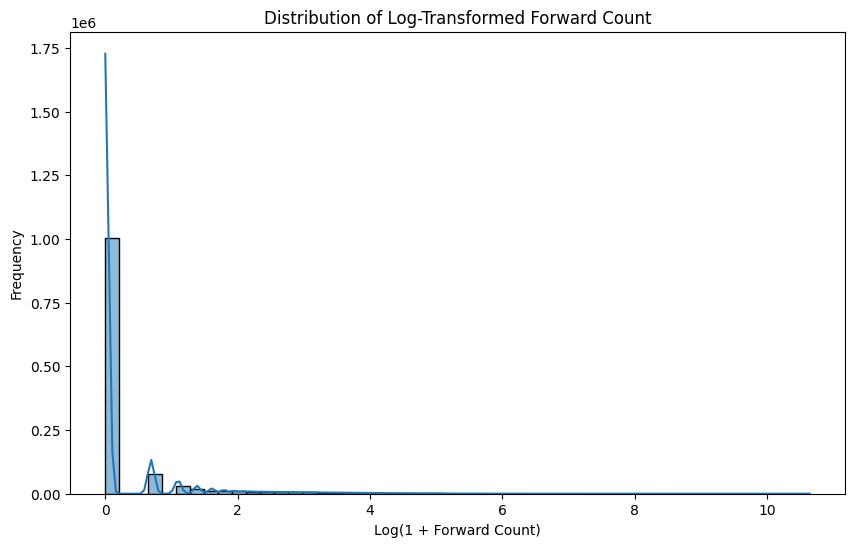

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(train_df['forward_count_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Forward Count')
plt.xlabel('Log(1 + Forward Count)')
plt.ylabel('Frequency')
plt.show()

### Distribution of `comment_count_log`

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


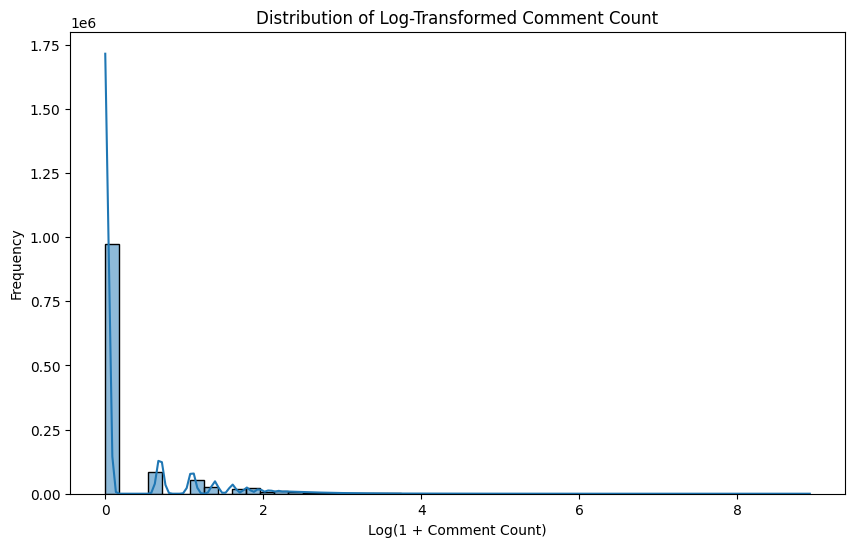

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(train_df['comment_count_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Comment Count')
plt.xlabel('Log(1 + Comment Count)')
plt.ylabel('Frequency')
plt.show()

### Distribution of `like_count_log`

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


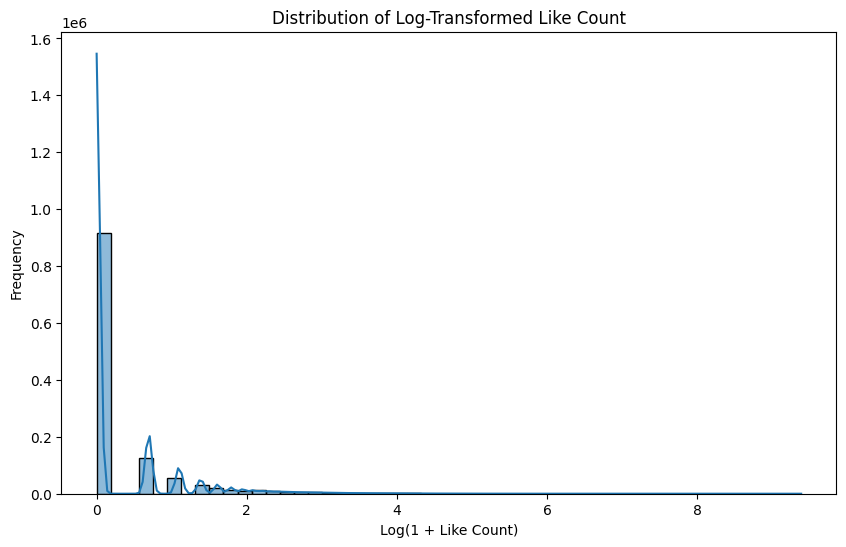

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.histplot(train_df['like_count_log'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Like Count')
plt.xlabel('Log(1 + Like Count)')
plt.ylabel('Frequency')
plt.show()

### Extracting Time-Based Features

In [8]:
# Extract hour and day of the week from the 'time' column
train_df['hour'] = train_df['time'].dt.hour
train_df['day_of_week'] = train_df['time'].dt.dayofweek # Monday=0, Sunday=6

print("--- Training Data Head with New Time-Based Features ---")
display(train_df[['time', 'hour', 'day_of_week']].head())

--- Training Data Head with New Time-Based Features ---


,time,hour,day_of_week
0,2015-02-23 17:41:29,17,0
1,2015-02-14 12:49:58,12,5
2,2015-03-31 13:58:06,13,1
3,2015-06-11 20:39:57,20,3
4,2015-03-10 18:02:38,18,1


### Engagement Counts by Hour of Day

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

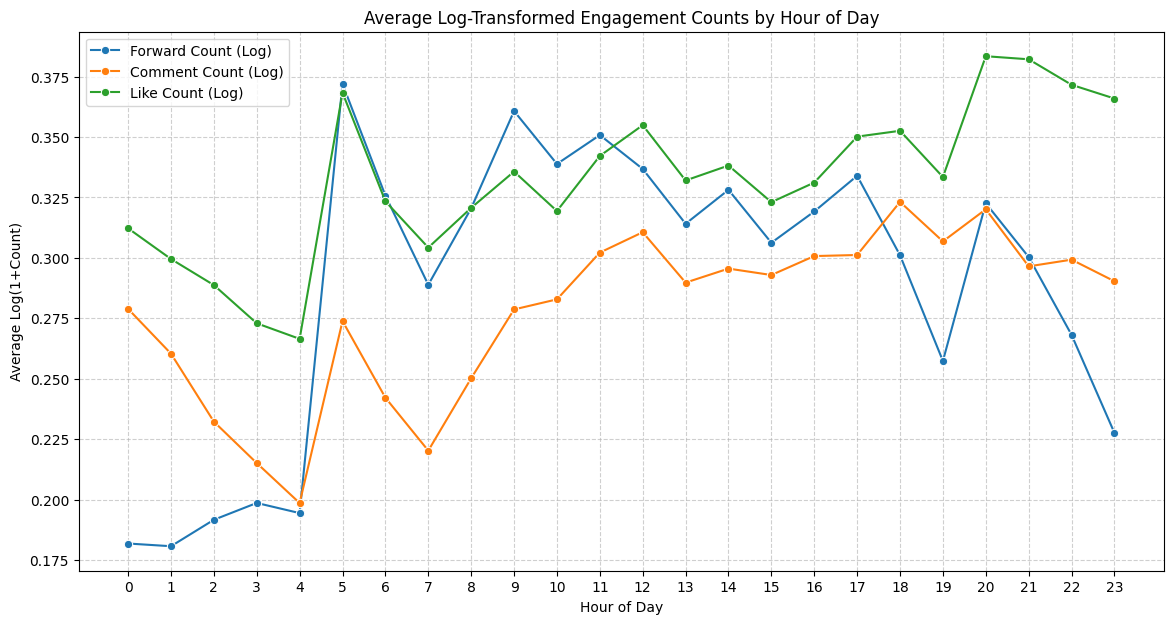

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by hour and calculate the mean of log-transformed engagement counts
hourly_engagement = train_df.groupby('hour')[['forward_count_log', 'comment_count_log', 'like_count_log']].mean().reset_index()

# Plotting hourly engagement
plt.figure(figsize=(14, 7))

sns.lineplot(x='hour', y='forward_count_log', data=hourly_engagement, label='Forward Count (Log)', marker='o')
sns.lineplot(x='hour', y='comment_count_log', data=hourly_engagement, label='Comment Count (Log)', marker='o')
sns.lineplot(x='hour', y='like_count_log', data=hourly_engagement, label='Like Count (Log)', marker='o')

plt.title('Average Log-Transformed Engagement Counts by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Log(1+Count)')
plt.xticks(range(0, 24)) # Ensure all hours are displayed on x-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Engagement Counts by Day of Week

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

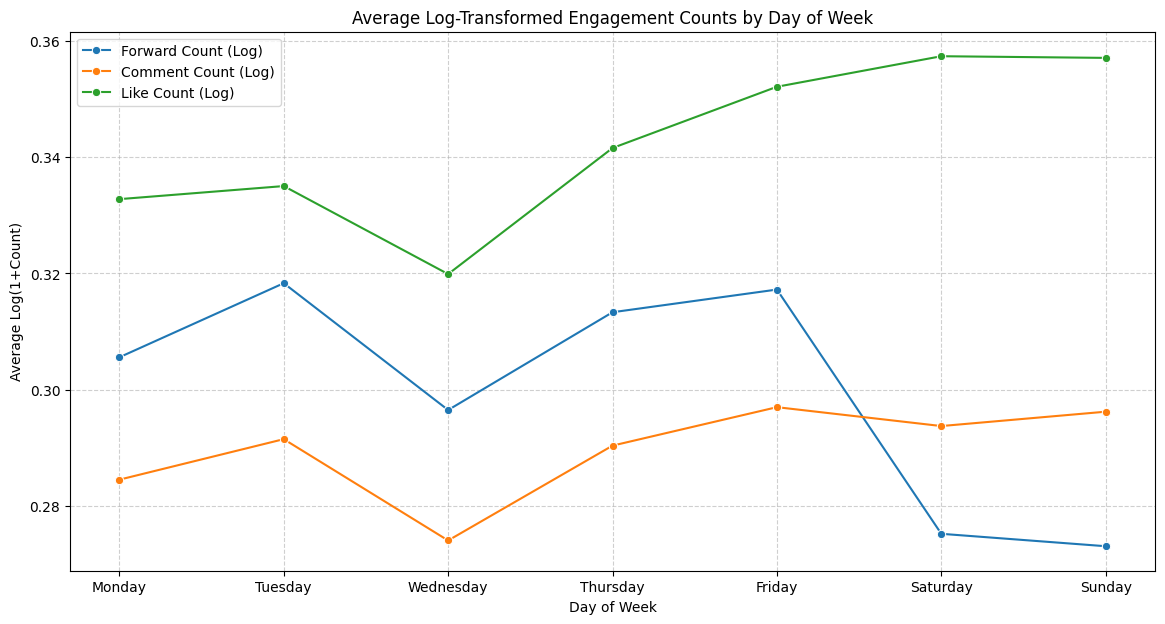

In [10]:
# Group by day of week and calculate the mean of log-transformed engagement counts
daily_engagement = train_df.groupby('day_of_week')[['forward_count_log', 'comment_count_log', 'like_count_log']].mean().reset_index()

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_engagement['day_name'] = daily_engagement['day_of_week'].map(lambda x: day_names[x])

# Plotting daily engagement
plt.figure(figsize=(14, 7))

sns.lineplot(x='day_name', y='forward_count_log', data=daily_engagement, label='Forward Count (Log)', marker='o')
sns.lineplot(x='day_name', y='comment_count_log', data=daily_engagement, label='Comment Count (Log)', marker='o')
sns.lineplot(x='day_name', y='like_count_log', data=daily_engagement, label='Like Count (Log)', marker='o')

plt.title('Average Log-Transformed Engagement Counts by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Log(1+Count)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

### Correlation Between Engagement Metrics and Hour of Day

Correlation with Hour of Day:


hour                 1.000000
forward_count_log    0.004916
comment_count_log    0.023776
like_count_log       0.027066
Name: hour, dtype: float64

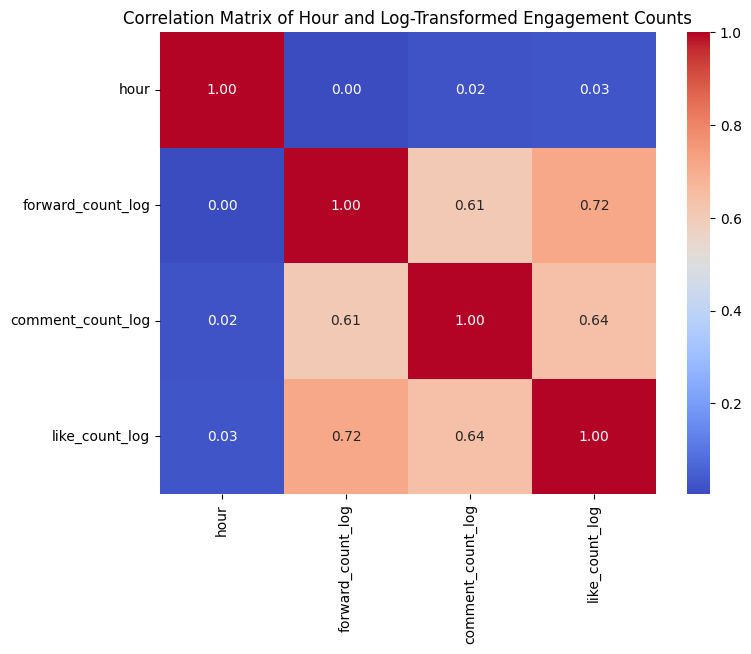

In [11]:
# Calculate the correlation between engagement metrics and 'hour'
correlation_with_hour = train_df[['hour', 'forward_count_log', 'comment_count_log', 'like_count_log']].corr()['hour']

print("Correlation with Hour of Day:")
display(correlation_with_hour)

# You can also visualize the correlation matrix for these columns
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[['hour', 'forward_count_log', 'comment_count_log', 'like_count_log']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Hour and Log-Transformed Engagement Counts')
plt.show()

### Correlation Between Engagement Metrics and Day of Week

Correlation with Day of Week:


day_of_week          1.000000
forward_count_log   -0.012718
comment_count_log    0.006611
like_count_log       0.014146
Name: day_of_week, dtype: float64

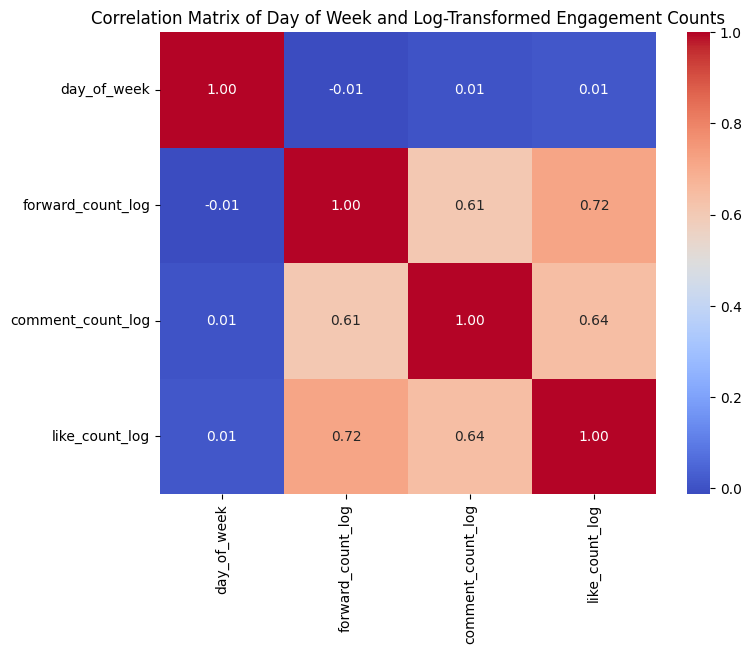

In [12]:
# Calculate the correlation between engagement metrics and 'day_of_week'
correlation_with_day_of_week = train_df[['day_of_week', 'forward_count_log', 'comment_count_log', 'like_count_log']].corr()['day_of_week']

print("Correlation with Day of Week:")
display(correlation_with_day_of_week)

# You can also visualize the correlation matrix for these columns
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[['day_of_week', 'forward_count_log', 'comment_count_log', 'like_count_log']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Day of Week and Log-Transformed Engagement Counts')
plt.show()

### Distribution of Text Lengths in `content` Column

--- Content Length Statistics ---


count    1.225085e+06
mean     7.378489e+01
std      1.164403e+02
min      1.000000e+00
25%      3.500000e+01
50%      6.600000e+01
75%      1.070000e+02
max      3.816700e+04
Name: content_length, dtype: float64

C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


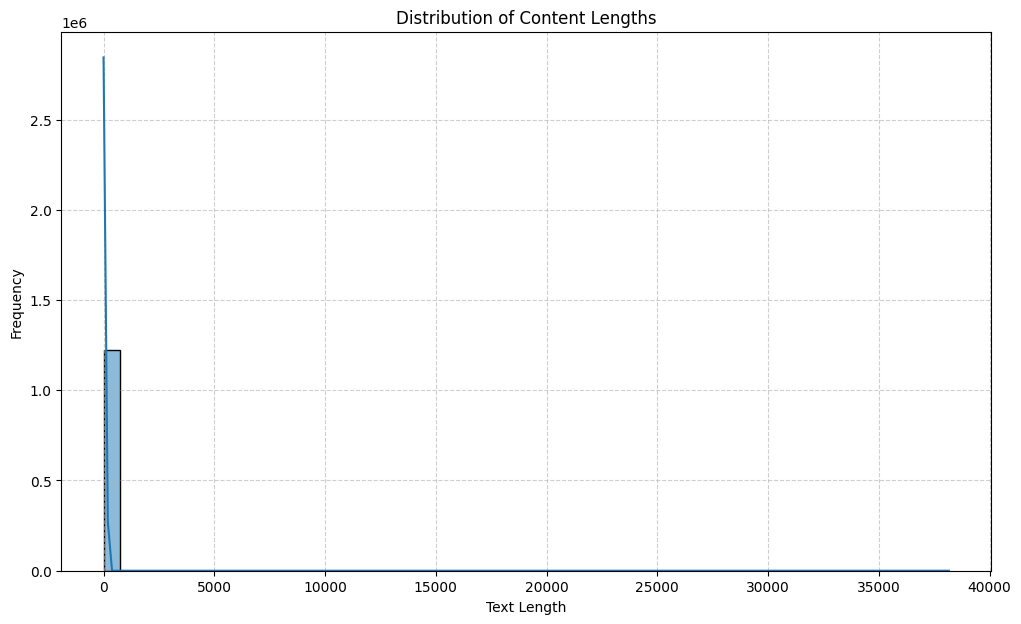

In [13]:
# Calculate the length of each text in the 'content' column
train_df['content_length'] = train_df['content'].apply(len)

# Display basic statistics of content length
print("--- Content Length Statistics ---")
display(train_df['content_length'].describe())

# Plot the distribution of content lengths
plt.figure(figsize=(12, 7))
sns.histplot(train_df['content_length'], bins=50, kde=True)
plt.title('Distribution of Content Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Sentiment Analysis on `content` Column

In [14]:
# Install the transformers library if you haven't already
# Install the transformers library if you haven't already
%pip install transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
%pip install torch
from transformers import pipeline

# Load a pre-trained sentiment analysis model
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

# Due to the large size of the dataset, we will apply sentiment analysis to a sample of the 'content' column
# Let's take a sample of 1000 posts for demonstration purposes.
sample_size = 1000
sample_content = train_df['content'].sample(n=sample_size, random_state=42).tolist()

# Perform sentiment analysis on the sample
sample_sentiment_results = sentiment_analyzer(sample_content)

# Add the results to a DataFrame for easier viewing
sentiment_df = pd.DataFrame(sample_sentiment_results)
sentiment_df['content'] = sample_content

print(f"--- Sentiment Analysis Results for a Sample of {sample_size} Posts ---")
display(sentiment_df.head())

# You can also get a distribution of sentiment labels
print("\n--- Sentiment Label Distribution in Sample ---")
display(sentiment_df['label'].value_counts())

  Using cached torch-2.11.0-cp311-cp311-win_amd64.whl.metadata (29 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.5 MB 4.2 MB/s eta 0:00:27
   ---------------------------------------- 0.5/114.5 MB 4.2 MB/s eta 0:00:27
   ---------------------------------------- 0.8/114.5 MB 987.4 kB/s eta 0:01:56
   ---------------------------------------- 1.3/114.5 MB 1.3 MB/s eta 0:01:25
    --------------------------------------- 1.6/114.5 MB 1.6 MB/s eta 0:01:10
   - -------------------------------------- 2.9/114.5 MB 2.3 MB/s eta 0:00:49
   - -------------------------------------- 3.7/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------------------------- 3.7/114.5 MB 2.4 MB/s eta 0:00:47
   - -------------------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\angel\AppData\Roaming\Python\Python311\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\angel\anaconda3\Lib\ht

RuntimeError: At least one of TensorFlow 2.0 or PyTorch should be installed. To install TensorFlow 2.0, read the instructions at https://www.tensorflow.org/install/ To install PyTorch, read the instructions at https://pytorch.org/.